In [1]:
!pip install -q diffusers transformers accelerate lpips torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.6 MB/s eta 0:00:00


In [2]:
!find /kaggle/working -mindepth 1 -maxdepth 1 ! -name 'data' -exec rm -rf {} +

In [3]:
# rm -rf /kaggle/working/*

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from diffusers import DDPMPipeline, DDPMScheduler
import lpips
import numpy as np
import matplotlib.pyplot as plt
import copy
import random
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

torch.manual_seed(101)
random.seed(101)
np.random.seed(101)

Using device: cuda


In [6]:
ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)
unet = ddpm_pipe.unet
scheduler: DDPMScheduler = ddpm_pipe.scheduler
scheduler.set_timesteps(1000)  # full schedule; we'll only use a slice of it


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [7]:
# DDPM was trained on images scaled to [-1, 1]
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

CLASSES = train_set.classes  # ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_indices_by_class(dataset, class_idx):
    return [i for i, (_, y) in enumerate(dataset) if y == class_idx]


In [8]:
class SurrogateResNet(nn.Module):
    """Small ResNet-ish CNN, fast to train on CIFAR-10 from scratch."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # -> 256-d feature vector
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x, return_features=False):
        feat = self.features(x).flatten(1)
        out = self.classifier(feat)
        if return_features:
            return out, feat
        return out


def train_surrogate(epochs=10, batch_size=128):
    model = SurrogateResNet().to(device)
    loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        print(f"[Surrogate] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    model.eval()
    return model

surrogate = train_surrogate(epochs=15)  # ~2-3 min on a T4


[Surrogate] epoch 1/15 loss=1.2409 acc=0.5518
[Surrogate] epoch 2/15 loss=0.8485 acc=0.7015
[Surrogate] epoch 3/15 loss=0.6835 acc=0.7606
[Surrogate] epoch 4/15 loss=0.5818 acc=0.8003
[Surrogate] epoch 5/15 loss=0.4980 acc=0.8279
[Surrogate] epoch 6/15 loss=0.4296 acc=0.8521
[Surrogate] epoch 7/15 loss=0.3797 acc=0.8680
[Surrogate] epoch 8/15 loss=0.3305 acc=0.8873
[Surrogate] epoch 9/15 loss=0.2886 acc=0.9013
[Surrogate] epoch 10/15 loss=0.2474 acc=0.9147
[Surrogate] epoch 11/15 loss=0.2045 acc=0.9298
[Surrogate] epoch 12/15 loss=0.1784 acc=0.9398
[Surrogate] epoch 13/15 loss=0.1509 acc=0.9492
[Surrogate] epoch 14/15 loss=0.1246 acc=0.9580
[Surrogate] epoch 15/15 loss=0.1049 acc=0.9655


In [9]:
lpips_fn = lpips.LPIPS(net='alex').to(device)
for p in lpips_fn.parameters():
    p.requires_grad_(False)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth



  0%|          | 0.00/233M [00:00<?, ?B/s]
  4%|▍         | 9.50M/233M [00:00<00:02, 99.5MB/s]
 14%|█▎        | 31.6M/233M [00:00<00:01, 177MB/s] 
 23%|██▎       | 54.6M/233M [00:00<00:00, 206MB/s]
 32%|███▏      | 74.4M/233M [00:00<00:00, 193MB/s]
 40%|████      | 93.5M/233M [00:00<00:00, 196MB/s]
 50%|████▉     | 116M/233M [00:00<00:00, 209MB/s] 
 58%|█████▊    | 136M/233M [00:00<00:00, 208MB/s]
 68%|██████▊   | 158M/233M [00:00<00:00, 215MB/s]
 77%|███████▋  | 179M/233M [00:00<00:00, 216MB/s]
 86%|████████▌ | 200M/233M [00:01<00:00, 215MB/s]
100%|██████████| 233M/233M [00:01<00:00, 208MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [10]:
def make_poison(
    base_img: torch.Tensor,       # [1,3,32,32] in [-1,1], true label = class A (stays clean-label)
    target_img: torch.Tensor,     # [1,3,32,32] in [-1,1], the test-time image we want misclassified
    surrogate_model: nn.Module,
    t_start: int = 100,           # how far to forward-diffuse (out of 1000). Lower = closer to original.
    guidance_scale: float = 20.0, # strength of feature-collision pull
    lpips_weight: float = 0.15,   # how much to penalize perceptual drift from base_img
    num_inference_steps: int = 50,
):
    """
    Returns a poisoned image that:
      - still visually/semantically belongs to base_img's true class (clean-label constraint)
      - has surrogate CNN features close to target_img's features (feature collision)
    """
    base_img = base_img.to(device)
    target_img = target_img.to(device)

    with torch.no_grad():
        _, target_feat = surrogate_model(target_img, return_features=True)

    # --- Step 1: partial forward diffusion (SDEdit) ---
    scheduler.set_timesteps(num_inference_steps)
    timesteps = scheduler.timesteps  # descending, e.g. [980, 960, ..., 0]

    # find the timestep index closest to t_start
    start_idx = (timesteps - t_start).abs().argmin().item()
    t0 = timesteps[start_idx]

    noise = torch.randn_like(base_img)
    x_t = scheduler.add_noise(base_img, noise, t0.unsqueeze(0))

    # --- Step 2: guided reverse diffusion ---
    # Only iterate over timesteps <= t0 (i.e. from start_idx to the end)
    active_timesteps = timesteps[start_idx:]

    x_t = x_t.detach().clone().requires_grad_(True)

    for t in active_timesteps:
        t_batch = t.unsqueeze(0).to(device)

        # predict noise (no grad needed through UNet weights, but we DO need
        # grad w.r.t. x_t, so keep it attached)
        noise_pred = unet(x_t, t_batch).sample

        # scheduler step gives us x_{t-1} AND the model's estimate of x0
        step_out = scheduler.step(noise_pred, t.item(), x_t)
        x_prev = step_out.prev_sample
        pred_x0 = step_out.pred_original_sample  # estimate of clean image at this step

        # --- guidance loss on the predicted clean image ---
        pred_x0_clamped = pred_x0.clamp(-1, 1)
        _, feat = surrogate_model(pred_x0_clamped, return_features=True)

        feature_collision_loss = F.mse_loss(feat, target_feat.detach())
        perceptual_loss = lpips_fn(pred_x0_clamped, base_img).mean()

        total_loss = feature_collision_loss - lpips_weight * (-perceptual_loss)
        # (we ADD lpips as a penalty, written this way to make sign explicit)
        total_loss = feature_collision_loss + lpips_weight * perceptual_loss

        grad = torch.autograd.grad(total_loss, x_t, retain_graph=False)[0]

        # nudge x_prev opposite the gradient direction (minimize loss),
        # scaled by guidance_scale and current noise level
        with torch.no_grad():
            x_prev = x_prev - guidance_scale * (t.item() / 1000.0) * grad

        x_t = x_prev.detach().clone().requires_grad_(True)

    poison_img = x_t.detach().clamp(-1, 1)
    return poison_img

generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25


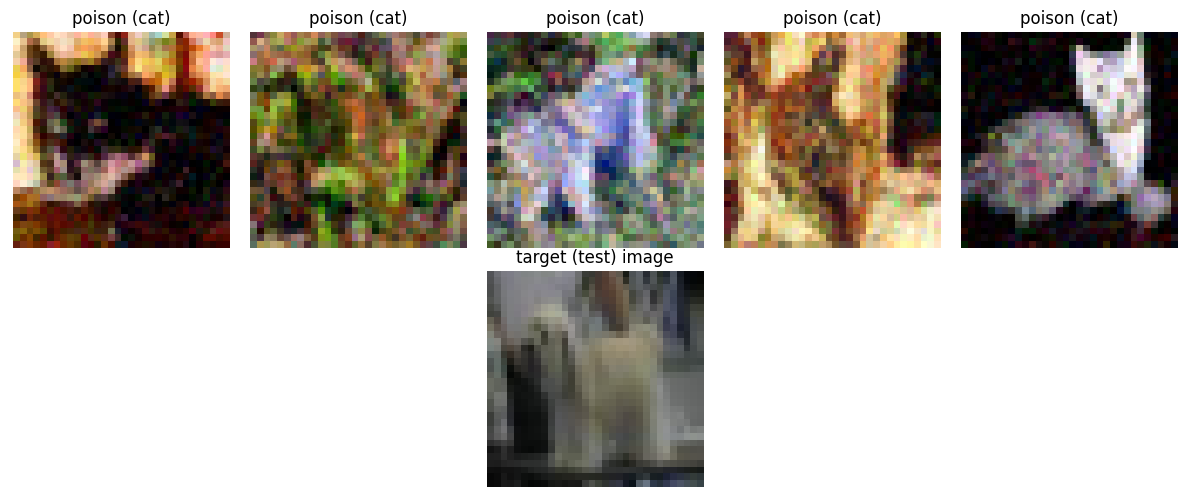

In [11]:
def denorm(img):
    """[-1,1] -> [0,1] for plotting"""
    return (img.clamp(-1, 1) + 1) / 2

def generate_poison_set(
    base_class_idx: int,
    target_class_idx: int,
    num_poisons: int = 25,
    t_start: int = 250,
):
    base_indices = get_indices_by_class(train_set, base_class_idx)
    target_indices = get_indices_by_class(test_set, target_class_idx)

    chosen_base = random.sample(base_indices, num_poisons)
    target_idx = random.choice(target_indices)
    target_img, _ = test_set[target_idx]
    target_img = target_img.unsqueeze(0)

    poisons = []
    for i, idx in enumerate(chosen_base):
        base_img, base_label = train_set[idx]
        base_img = base_img.unsqueeze(0)
        poison = make_poison(base_img, target_img, surrogate, t_start=t_start)
        poisons.append((idx, poison.cpu(), base_label))
        print(f"generated poison {i+1}/{num_poisons}")

    return poisons, target_img, target_idx


# Example: poison "cat" images to collide with a "dog" target image
poisons, target_img, target_idx = generate_poison_set(
    base_class_idx=CLASSES.index("cat"),
    target_class_idx=CLASSES.index("dog"),
    num_poisons=25,
    t_start=250,
)

# --- visualize a few ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(denorm(poisons[i][1][0]).permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"poison ({CLASSES[poisons[i][2]]})")
    axes[0, i].axis("off")
axes[1, 2].imshow(denorm(target_img[0]).permute(1, 2, 0).numpy())
axes[1, 2].set_title("target (test) image")
axes[1, 2].axis("off")
for i in [0, 1, 3, 4]:
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig("poison_examples.png", dpi=150)
plt.show()


In [12]:
class PoisonedCIFAR10(torch.utils.data.Dataset):
    """CIFAR-10 dataset with selected samples replaced by poison images."""

    def __init__(self, clean_dataset, poisons):
        self.clean_dataset = clean_dataset

        # Map original CIFAR-10 index -> poison
        self.poisons = {
            idx: (img, label)
            for idx, img, label in poisons
        }

    def __len__(self):
        return len(self.clean_dataset)

    def __getitem__(self, idx):
        if idx in self.poisons:
            img, label = self.poisons[idx]

            if img.dim() == 4:
                img = img.squeeze(0)

            return img, label

        return self.clean_dataset[idx]

In [13]:
def train_victim(dataset, epochs=8, batch_size=256):
    """Victim CNN — architecture can differ from surrogate to test transferability."""
    model = SurrogateResNet().to(device)  # swap for a different arch if you want to test transfer
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        print(f"[Victim] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    model.eval()
    return model


poisoned_dataset = PoisonedCIFAR10(train_set, poisons)
victim_clean = train_victim(train_set, epochs=8)      # baseline, no poisoning
victim_poisoned = train_victim(poisoned_dataset, epochs=8)  # with poisons injected


[Victim] epoch 1/8 loss=1.3017 acc=0.5313
[Victim] epoch 2/8 loss=0.9056 acc=0.6796
[Victim] epoch 3/8 loss=0.7365 acc=0.7442
[Victim] epoch 4/8 loss=0.6246 acc=0.7825
[Victim] epoch 5/8 loss=0.5419 acc=0.8117
[Victim] epoch 6/8 loss=0.4770 acc=0.8367
[Victim] epoch 7/8 loss=0.4178 acc=0.8571
[Victim] epoch 8/8 loss=0.3693 acc=0.8732
[Victim] epoch 1/8 loss=1.2971 acc=0.5313
[Victim] epoch 2/8 loss=0.9021 acc=0.6821
[Victim] epoch 3/8 loss=0.7307 acc=0.7440
[Victim] epoch 4/8 loss=0.6244 acc=0.7816
[Victim] epoch 5/8 loss=0.5398 acc=0.8130
[Victim] epoch 6/8 loss=0.4731 acc=0.8376
[Victim] epoch 7/8 loss=0.4135 acc=0.8597
[Victim] epoch 8/8 loss=0.3683 acc=0.8754


In [14]:
def evaluate_clean_accuracy(model, dataset, batch_size=512):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


def check_target_misclassified(model, target_img, target_true_label, base_class_idx):
    with torch.no_grad():
        out = model(target_img.to(device))
        pred = out.argmax(1).item()
    print(f"Target true label: {CLASSES[target_true_label]}")
    print(f"Predicted by clean-trained victim / poisoned victim: {CLASSES[pred]}")
    attack_success = (pred == base_class_idx)  # misclassified AS the poison's base class
    return attack_success, pred

def evaluate_target_class_asr(
    model,
    dataset,
    target_class_idx,
    base_class_idx,
    batch_size=512,
):
    """
    Targeted ASR:
    Among all samples belonging to target_class_idx,
    calculate the fraction classified as base_class_idx.
    """
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )

    total_targets = 0
    successful_attacks = 0

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Only evaluate images from the target class
            mask = (y == target_class_idx)

            if not mask.any():
                continue

            x_target = x[mask].to(device)

            out = model(x_target)
            pred = out.argmax(dim=1)

            successful_attacks += (pred == base_class_idx).sum().item()
            total_targets += x_target.size(0)

    asr = successful_attacks / total_targets if total_targets > 0 else 0.0

    return asr, successful_attacks, total_targets


target_true_label = test_set.targets[target_idx]
base_class_idx = CLASSES.index("cat")

print("\n=== CLEAN ACCURACY ===")
acc_clean_model = evaluate_clean_accuracy(victim_clean, test_set)
acc_poisoned_model = evaluate_clean_accuracy(victim_poisoned, test_set)
print(f"Clean-trained victim test accuracy:    {acc_clean_model:.4f}")
print(f"Poison-trained victim test accuracy:   {acc_poisoned_model:.4f}  (should stay close to clean — that's the 'clean-label' property)")

print("\n=== ATTACK SUCCESS (single target) ===")
success_before, pred_before = check_target_misclassified(victim_clean, target_img, target_true_label, base_class_idx)
success_after, pred_after = check_target_misclassified(victim_poisoned, target_img, target_true_label, base_class_idx)
print(f"Misclassified as '{CLASSES[base_class_idx]}' BEFORE poisoning: {success_before}")
print(f"Misclassified as '{CLASSES[base_class_idx]}' AFTER poisoning:  {success_after}")

print("\n=== TARGET-CLASS ATTACK SUCCESS RATE ===")

target_class_idx = CLASSES.index("dog")
base_class_idx = CLASSES.index("cat")

asr_clean, success_clean, total_targets = evaluate_target_class_asr(
    victim_clean,
    test_set,
    target_class_idx,
    base_class_idx,
)

asr_poisoned, success_poisoned, _ = evaluate_target_class_asr(
    victim_poisoned,
    test_set,
    target_class_idx,
    base_class_idx,
)

print(
    f"Clean model ASR:    "
    f"{success_clean}/{total_targets} = {asr_clean:.4f} "
    f"({asr_clean * 100:.2f}%)"
)

print(
    f"Poisoned model ASR: "
    f"{success_poisoned}/{total_targets} = {asr_poisoned:.4f} "
    f"({asr_poisoned * 100:.2f}%)"
)

print(
    f"ASR increase: "
    f"{(asr_poisoned - asr_clean):.4f} "
    f"({(asr_poisoned - asr_clean) * 100:.2f} percentage points)"
)


=== CLEAN ACCURACY ===
Clean-trained victim test accuracy:    0.7247
Poison-trained victim test accuracy:   0.7810  (should stay close to clean — that's the 'clean-label' property)

=== ATTACK SUCCESS (single target) ===
Target true label: dog
Predicted by clean-trained victim / poisoned victim: dog
Target true label: dog
Predicted by clean-trained victim / poisoned victim: bird
Misclassified as 'cat' BEFORE poisoning: False
Misclassified as 'cat' AFTER poisoning:  False

=== TARGET-CLASS ATTACK SUCCESS RATE ===
Clean model ASR:    8/1000 = 0.0080 (0.80%)
Poisoned model ASR: 337/1000 = 0.3370 (33.70%)
ASR increase: 0.3290 (32.90 percentage points)


In [15]:
print("\n=== POISON CHECK ===")

for i, (idx, poison_img, label) in enumerate(poisons):
    print(
        f"Poison {i}: "
        f"train_idx={idx}, "
        f"label={label} ({CLASSES[label]}), "
        f"original_label={train_set[idx][1]} ({CLASSES[train_set[idx][1]]})"
    )


=== POISON CHECK ===
Poison 0: train_idx=47804, label=3 (cat), original_label=3 (cat)
Poison 1: train_idx=15826, label=3 (cat), original_label=3 (cat)
Poison 2: train_idx=44322, label=3 (cat), original_label=3 (cat)
Poison 3: train_idx=29154, label=3 (cat), original_label=3 (cat)
Poison 4: train_idx=38442, label=3 (cat), original_label=3 (cat)
Poison 5: train_idx=4110, label=3 (cat), original_label=3 (cat)
Poison 6: train_idx=41513, label=3 (cat), original_label=3 (cat)
Poison 7: train_idx=17410, label=3 (cat), original_label=3 (cat)
Poison 8: train_idx=49430, label=3 (cat), original_label=3 (cat)
Poison 9: train_idx=17926, label=3 (cat), original_label=3 (cat)
Poison 10: train_idx=23348, label=3 (cat), original_label=3 (cat)
Poison 11: train_idx=39921, label=3 (cat), original_label=3 (cat)
Poison 12: train_idx=17184, label=3 (cat), original_label=3 (cat)
Poison 13: train_idx=26613, label=3 (cat), original_label=3 (cat)
Poison 14: train_idx=36080, label=3 (cat), original_label=3 (cat)

In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

def get_confusion_matrix(model, dataset, num_classes=10, batch_size=512):
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            preds = out.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    return confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(num_classes))
    )

In [17]:
cm_clean = get_confusion_matrix(victim_clean, test_set)
cm_poisoned = get_confusion_matrix(victim_poisoned, test_set)

print("\n=== CONFUSION MATRIX: CLEAN ===")
print(cm_clean)

print("\n=== CONFUSION MATRIX: POISONED ===")
print(cm_poisoned)


=== CONFUSION MATRIX: CLEAN ===
[[598  57  74  14  11  25  14  71 115  21]
 [  1 967   0   1   0  10   0   5   3  13]
 [ 14   8 616  12  22 195  55  70   7   1]
 [  0   6  23 292  11 594  19  44   8   3]
 [  2   3  44  20 510 227  18 169   7   0]
 [  0   1  11   8   3 942   0  34   1   0]
 [  1   3  17  20  11 170 751  24   2   1]
 [  1   0   1   0   3  99   0 896   0   0]
 [ 12  43   1   2   0  12   5  13 899  13]
 [  3 141   0   1   1  31   1  34  12 776]]

=== CONFUSION MATRIX: POISONED ===
[[825  10  20  10   4   0   3  18 106   4]
 [ 19 909   1   6   3   1   2   0  51   8]
 [ 69   1 741  60  61   4  21  32  11   0]
 [ 30   6  57 775  40  13  14  41  23   1]
 [  9   2  57  52 802   4   9  55  10   0]
 [ 14   4  55 337  43 472   9  58   8   0]
 [ 12   1  32  86  57   1 790   7  13   1]
 [ 18   0  24  41  26   5   1 884   0   1]
 [ 24   7   2   3   1   0   2   6 955   0]
 [ 56 133   3  17   2   0   2  14 116 657]]


In [18]:
print("Original dataset size:", len(train_set))
print("Poisoned dataset size:", len(poisoned_dataset))

Original dataset size: 50000
Poisoned dataset size: 50000


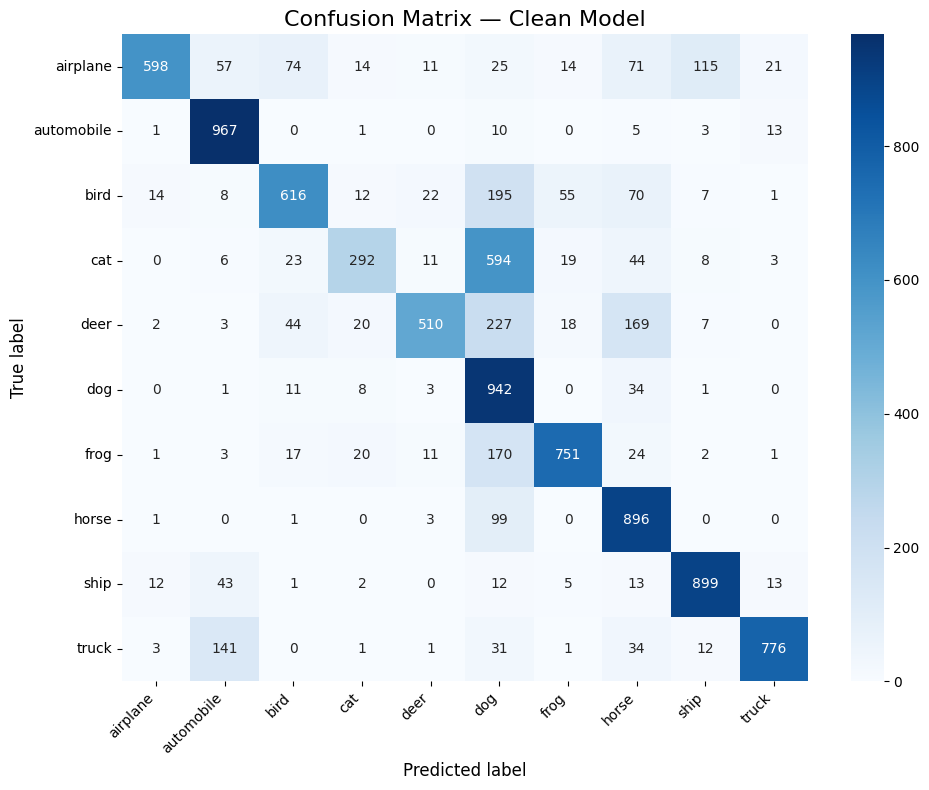

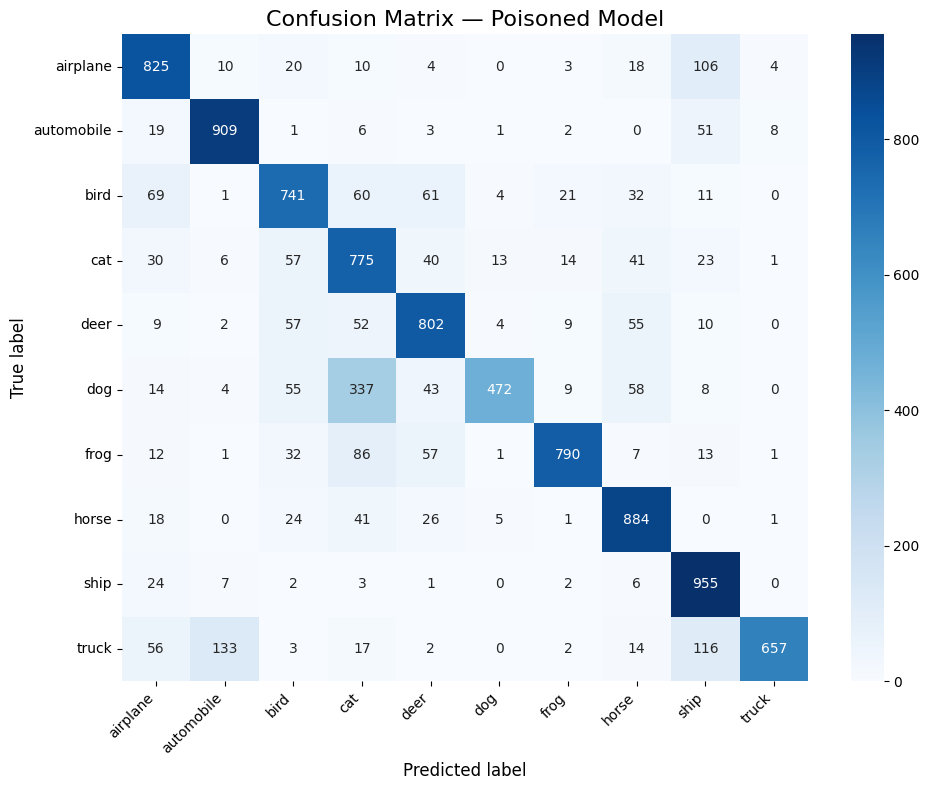

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

CLASSES = train_set.classes

def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar=True
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# Clean model
plot_confusion_matrix(
    cm_clean,
    CLASSES,
    "Confusion Matrix — Clean Model"
)

# Poisoned model
plot_confusion_matrix(
    cm_poisoned,
    CLASSES,
    "Confusion Matrix — Poisoned Model"
)